In [38]:
import os
import sys

repo_url = "https://github.com/chahineNejm/kernels_playground"
repo_name = repo_url.split("/")[-1]
%cd /content
if os.path.exists(repo_name):
    print(f"🗑️ Wiping old '{repo_name}' to clear out local changes...")
    !rm -rf {repo_name}

print(f"📥 Cloning fresh '{repo_name}'...")
!git clone {repo_url}

repo_path = os.path.abspath(repo_name)
if repo_path not in sys.path:
    sys.path.append(repo_path)
%cd {repo_name}

req_file = "first_tests/requirements.txt"
if os.path.exists(req_file):
    print("⚙️ Installing dependencies...")
    !pip install -q -r {req_file}

%load_ext autoreload
%autoreload 2
%cd first_tests

print("\n✅ Fresh setup complete! You are now inside the 'first_tests' folder.")

/content
🗑️ Wiping old 'kernels_playground' to clear out local changes...
📥 Cloning fresh 'kernels_playground'...
Cloning into 'kernels_playground'...
remote: Enumerating objects: 132, done.
remote: Counting objects: 100% (132/132), done.
remote: Compressing objects: 100% (94/94), done.
remote: Total 132 (delta 45), reused 107 (delta 31), pack-reused 0 (from 0)
Receiving objects: 100% (132/132), 32.05 MiB | 20.14 MiB/s, done.
Resolving deltas: 100% (45/45), done.
/content/kernels_playground
⚙️ Installing dependencies...
The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
/content/kernels_playground/first_tests

✅ Fresh setup complete! You are now inside the 'first_tests' folder.


In [39]:
import numpy as np
import matplotlib.pyplot as plt

import importlib


# local utils package
from utils.config import DEFAULT_CONFIG
from utils.data import (
    load_gift_dataset, quick_peek, dataset_summary, build_examples,
    normalize_by_history,prepare_examples
)
from utils.kernels import (fit_kernel_operator, predict_kernel_operator, rmse, relative_rmse,
RBFKernel, DTWKernel, LinearKernel)
from utils.viz import (
    plot_series, plot_series_grid, plot_distribution,
    plot_train_test_split, plot_kernel_heatmap,
    plot_residuals, plot_metric_summary,
    plot_predictions_for_domain,report_eval,compare_results,
)
from utils.pipeline import train_eval, run_all_domains

## Configuration
Override any defaults here.

In [40]:
cfg = {
    **DEFAULT_CONFIG,
    "CONFIGS": {
        "Energy": "electricity_H_long",
        "Cloud":   "bitbrains_fast_storage_5T_long",
        "Traffic": "loop_seattle_H_long",
        "Solar":   "solar_H_long",
    },
    "N_SAMPLES_TO_LOAD": 5000,
    "N_TEST_SAMPLES": 200,
}
cfg

{'DATASET_NAME': 'Salesforce/GiftEvalParquet',
 'CONFIGS': {'Energy': 'electricity_H_long',
  'Cloud': 'bitbrains_fast_storage_5T_long',
  'Traffic': 'loop_seattle_H_long',
  'Solar': 'solar_H_long'},
 'N_SAMPLES_TO_LOAD': 5000,
 'N_TEST_SAMPLES': 200,
 'RANDOM_SEED': 0,
 'GAMMA': 0.01,
 'PAIRWISE_MEDIAN_SUBSET': 24,
 'HISTORY_CONTEXT_TO_PLOT': 240,
 'SAVE_FIGURE': True,
 'SHOW_FIGURES': True,
 'OUTPUT_STEM': 'kernel_operator_forecast'}

## Quick dataset exploration
Use these to poke around any config before running the full pipeline.

history: (31464,)  future: (720,)


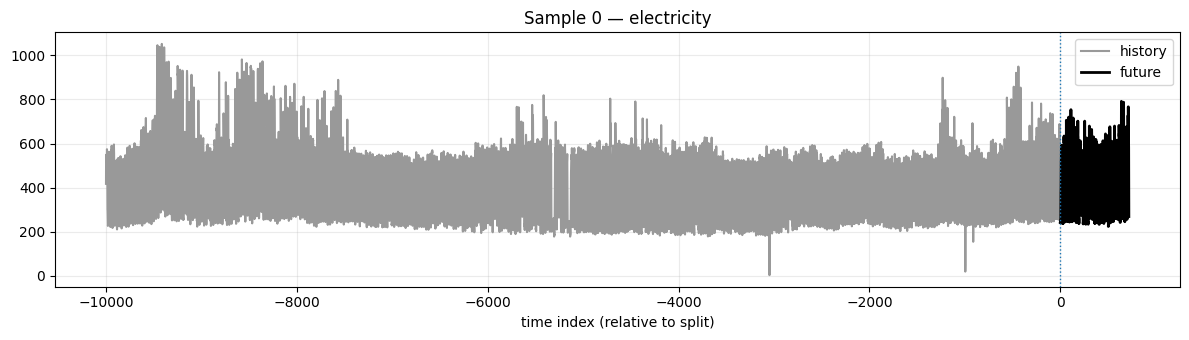

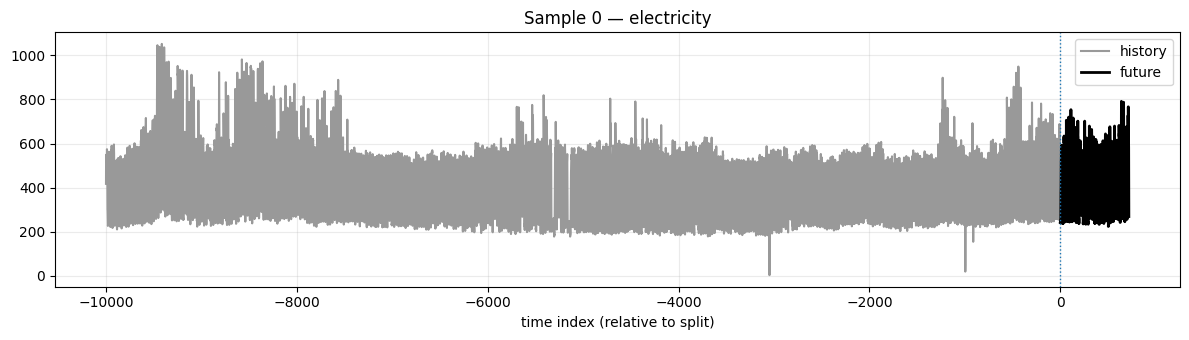

In [41]:
# Peek at one sample
sample = quick_peek(index=1535, config="Energy")
print(f"history: {sample['history'].shape}  future: {sample['future'].shape}")
plot_series(sample["history"], sample["future"], title="Sample 0 — electricity", history_context=10000,show=False)

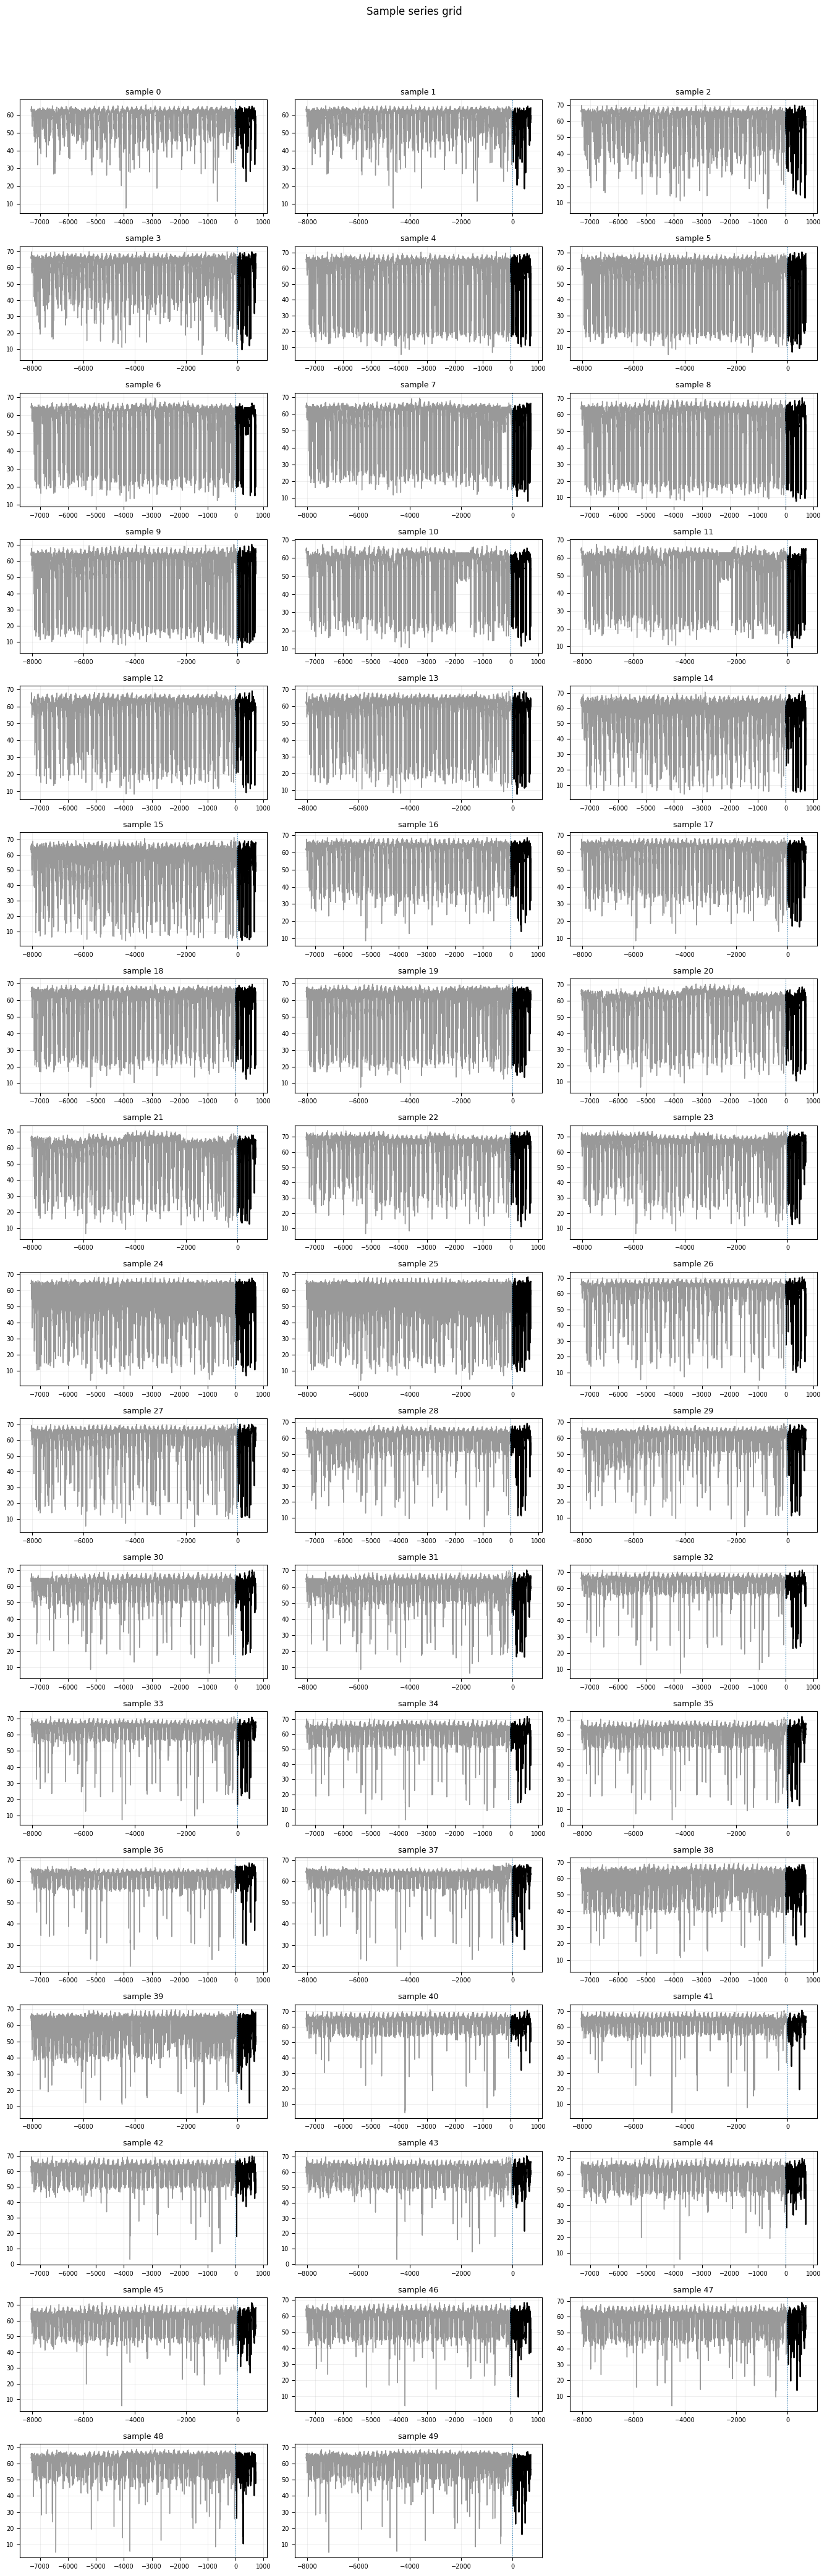

In [42]:
# Grid view of several samples
examples_preview = build_examples(config="Traffic", start=0, stop =50 ,step = 1)
plot_series_grid(examples_preview)

## Full kernel‑operator pipeline

In [43]:
raw = build_examples("Cloud", start=0, stop=500, step=4)
lengths = [(len(e["history"]), len(e["future"])) for e in raw]
print(f"History range: {min(l[0] for l in lengths)} – {max(l[0] for l in lengths)}")
print(f"Future range:  {min(l[1] for l in lengths)} – {max(l[1] for l in lengths)}")

examples = prepare_examples(
    raw,
    history_len=int(1E4),
    future_len=700,
    min_history=1000,       # drop anything shorter than this
    min_future=10,         # drop anything shorter than this
)



History range: 7200 – 7200
Future range:  720 – 720


In [47]:
#fucked up the ratio :)
my_train_indices = range(0, int(len(examples)*3/4), 4)
resultRBF = train_eval(examples, kernel=RBFKernel(),train_indices=my_train_indices)
resultRBF5 = train_eval(examples, kernel=RBFKernel(lengthscale=5.0),train_indices=my_train_indices)
resultDTW = train_eval(examples, kernel=DTWKernel(window=10),train_indices=my_train_indices)
resultL = train_eval(examples, kernel=LinearKernel(),train_indices=my_train_indices)

[] split: 24 train, 101 test
[] fitted: RBFKernel(lengthscale=141.30008391128086)  l=141.3001  gamma=1.00e-02
[] done - mean relRMSE=1.0099
[] split: 24 train, 101 test
[] fitted: RBFKernel(lengthscale=5.0)  l=5.0000  gamma=1.00e-02
[] done - mean relRMSE=1.0115
[] split: 24 train, 101 test


Calculating DTW Matrix:   0%|          | 0/576 [00:00<?, ?it/s]

Calculating DTW Matrix:   0%|          | 0/576 [00:00<?, ?it/s]

[] fitted: DTWKernel(sigma=133.6391195996398, window=10)    gamma=1.00e-02


Calculating DTW Matrix:   0%|          | 0/24 [00:00<?, ?it/s]

...

Calculating DTW Matrix:   0%|          | 0/24 [00:00<?, ?it/s]

Calculating DTW Matrix:   0%|          | 0/24 [00:00<?, ?it/s]

Calculating DTW Matrix:   0%|          | 0/24 [00:00<?, ?it/s]

Calculating DTW Matrix:   0%|          | 0/24 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [ ]:
#plot_predictions_for_domain("Traffic", result.test_records, result.predictions,history_context=1000)